In [ ]:
from __future__ import print_function, division
import sys,os
import numpy as np # type: ignore
import matplotlib.pyplot as plt # type: ignore
import pandas as pd
import matplotlib.cm as cm

from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import Normalize
from matplotlib.ticker import FuncFormatter
from matplotlib.ticker import ScalarFormatter

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib import cbook
import imageio
import os
from scipy.ndimage import gaussian_filter


%matplotlib inline 
font = {
        'weight' : 'bold',
        'size'   : 16}
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}\usepackage{newtxtext,newtxmath}')
plt.rc('font', **font) 

figures_path = "../figs"
model = "EHM_Itensor" 
exec = "Phase_Diagram"
results = "../results"
theme = "viridis"

fig_path = f"{figures_path}/{model}_{exec}/XXXXX"

In [80]:
N_Points = 50
L = 5

In [81]:
# Order parameters
def m_SDW(L, Sj): 
    m_sdw = 0
    for j in range(L):
        m_sdw += (-1)**(j) * (Sj[j])
    return m_sdw / L

def m_CDW(L, nj):
    m_cdw = 0
    for j in range(L):
        m_cdw += (-1)**(j) * (nj[j] - 1)
    return m_cdw / L 

In [82]:
def load_scalar_data(results, model, exec, L, N_Points):
    info_input = f"{results}/{model}_{exec}/scalars_{model}_{exec}_L={L}_NPoints={N_Points}.csv"
    df = pd.read_csv(info_input)

    U_vals = np.sort(df['U'].unique())
    V_vals = np.sort(df['V'].unique())

    U_unique = np.sort(df['U'].unique())
    V_unique = np.sort(df['V'].unique())

    nU = len(U_vals)
    nV = len(V_vals)
    
    Q_2 =           df['Q_2'].values.reshape(nV, nU).T
    Q_2_bits = df['Q_2_bits'].values.reshape(nV, nU).T

    avg_linear_entropy = df['coh_1rdm'].values.reshape(nV, nU).T
    quantum_coherence_2 = df['coh_2rdm'].values.reshape(nV, nU).T

    E_p =           df['E_p'].values.reshape(nV, nU).T
    E_p_bits = df['E_p_bits'].values.reshape(nV, nU).T
    E_GS =         df['E_GS'].values.reshape(nV, nU).T

    m_sdw = abs(df['m_sdw'].values.reshape(nV, nU).T)
    m_cdw = abs(df['m_cdw'].values.reshape(nV, nU).T)

    avg_linear_entropy = df['S'].values.reshape(nV, nU).T

    return df, U_vals, V_vals, U_unique, V_unique, m_sdw, m_cdw, avg_linear_entropy, E_GS, E_p, E_p_bits, avg_linear_entropy, Q_2, Q_2_bits, quantum_coherence_2

In [83]:
def load_vec_data(nV, nU, U_unique, V_unique, L, model, results, exec, N_Points):
    magnetization = np.zeros((nV, nU, L))
    charge_density = np.zeros((nV, nU, L))
    doublons = np.zeros((nV, nV, L))

    ent_spec_1rdm = np.zeros((nV, nV, 2*L))
    ent_spec_2rdm = np.zeros((nV, nV, L*(2*L-1)))

    info_input = f"{results}/{model}_{exec}/vector_measures_{model}_{exec}_L={L}_NPoints={N_Points}.csv"
    df_vecs = pd.read_csv(info_input)

    # Loading the 1-dimensional data frame values. 

    def parse_array(cell):
        return np.fromstring(cell.replace(";;", "").replace(";", ","), sep=",")

    # Apply parsing
    df_vecs["magnetization"] = df_vecs["magnetization"].apply(parse_array)
    df_vecs["charge_density"] = df_vecs["charge_density"].apply(parse_array)
    df_vecs["doublons"] = df_vecs["doublons"].apply(parse_array)
    # df_vecs["Omega_1rdm"] = df_vecs["Omega_1rdm"].apply(parse_array)
    # df_vecs["Omega_2rdm"] = df_vecs["Omega_2rdm"].apply(parse_array)

    # thanks gpt
    for _, row in df_vecs.iterrows():
        i = np.where(V_unique == row["V"])[0][0]
        j = np.where(U_unique == row["U"])[0][0]
        magnetization[i, j] = row["magnetization"]
        charge_density[i, j] = row["charge_density"]
        doublons[i, j] = row["doublons"]

        # ent_spec_1rdm[i, j] = row["Omega_1rdm"]
        # ent_spec_2rdm[i, j] = row["Omega_2rdm"]

    return magnetization, charge_density, doublons, ent_spec_1rdm, ent_spec_2rdm

In [84]:
df, U_vals, V_vals, U_unique, V_unique, m_sdw, m_cdw, avg_linear_entropy, E_GS, E_p, E_p_bits, quantum_coherence_1, Q_2, Q_2_bits, quantum_coherence_2  = load_scalar_data(results, model, exec, L, N_Points)

U_min, U_max = U_vals.min(), U_vals.max()
V_min, V_max = V_vals.min(), V_vals.max()

nU, nV = len(U_vals), len(V_vals)

In [85]:
magnetization, charge_density, doublons, ent_spec_1rdm, ent_spec_2rdm = load_vec_data(nV, nU, U_unique, V_unique, L, model, results, exec, N_Points)

In [86]:
tmp = df['E_p'].values.reshape(nV, nU).T

U_target = 5.51
i_U_fixed = np.argmin(np.abs(U_vals - U_target))

print(tmp[i_U_fixed, :])

[0.01461132 0.01447992 0.0143392  0.01420028 0.01406051 0.01392045
 0.01378082 0.01364242 0.01350638 0.01337368 0.01324571 0.01312394
 0.01301008 0.01290611 0.01281426 0.01273712 0.01267763 0.01263913
 0.01262546 0.01264097 0.01269061 0.01278    0.01291547 0.01310418
 0.01335418 0.01367451 0.01407526 0.01456771 0.0151644  0.01587926
 0.01672772 0.01772682 0.01889542 0.02025424 0.02182617 0.02363635
 0.02571252 0.02808525 0.03078836 0.03385946 0.03734063 0.04127945
 0.04573028 0.05075586 0.05642908 0.06283487 0.07007238 0.07825743
 0.08752449 0.09802613]


In [87]:
# gaps_1rdm = np.diff(ent_spec_1rdm)#[0, 0]
# gaps_2rdm = np.diff(ent_spec_2rdm)#[0, 0]

In [ ]:


def plot_phase_diagram(measure, U_vals, V_vals, x_label, y_label, measure_label, fname, 
                       x_min=0.0, y_min=0.0, theme="viridis", num_ticks=5, upper_bound=None, highlight=False):

    fig, ax1 = plt.subplots(1, 1, figsize=(8, 6))

    sigma_smoothing = 1.5
    num_contour_levels = 20

    U_min = x_min
    U_max = np.max(U_vals)
    V_min = y_min
    V_max = np.max(V_vals)

    # --- Mask and smoothing ---
    mask_U = (U_vals >= U_min) & (U_vals <= U_max)
    mask_V = (V_vals >= V_min) & (V_vals <= V_max)

    U_vals_new = U_vals[mask_U]
    V_vals_new = V_vals[mask_V]

    masked_measure = measure[np.ix_(mask_V, mask_U)]
    smoothed_measure = gaussian_filter(masked_measure, sigma=sigma_smoothing)

    X, Y = np.meshgrid(U_vals_new, V_vals_new)

    # --- Normalization ---
    vmin = np.nanmin(smoothed_measure)
    vmax = np.nanmax(smoothed_measure) if upper_bound is None else upper_bound
    norm = Normalize(vmin=vmin, vmax=vmax)

    # --- Main image ---
    im0 = ax1.imshow(
        smoothed_measure,
        origin="lower",
        extent=[U_min, U_max, V_min, V_max],
        aspect="auto",
        cmap=theme,
        norm=norm,
    )

    ax1.tick_params(axis='x', labelsize=18)
    ax1.tick_params(axis='y', labelsize=18)


    ax1.set_xlabel(x_label, fontsize=22)
    # ax1.set_ylabel(y_label, fontsize=22)

    # --- COLORBAR ON TOP ---
    pos = ax1.get_position()
    cax = fig.add_axes([pos.x0, -0.06, pos.width, 0.03])

    ticks = np.linspace(vmin, vmax, num_ticks)

    cbar = fig.colorbar(
        im0,
        cax=cax,
        orientation="horizontal",
        ticks=ticks,
        boundaries=np.linspace(vmin, vmax, 256)
    )

    cbar.ax.xaxis.set_ticks_position("bottom")

    # --- Fixed decimal formatting for clean tick labels ---
    def clean_tick(x, _):
        # format to one decimal place and remove trailing .0 if unnecessary
        s = f"{x:.1f}"
        if s.endswith(".0"):
            s = s[:-2]
        return f"${s}$"

    cbar.ax.xaxis.set_major_formatter(FuncFormatter(clean_tick))
    cbar.ax.tick_params(labelsize=14)

    # --- Contours ---
    ax1.contour(X, Y, smoothed_measure, levels=num_contour_levels, colors='black', linewidths=0.5)

    if (x_min == np.min(U_vals)) and (y_min == np.min(V_vals)) and highlight:
        ax1.hlines(y=0.0, xmin=0.0, xmax=np.max(U_vals), color='w', linestyle=':', linewidth=1.5)
        ax1.vlines(x=0.0, ymin=0.0, ymax=np.max(V_vals), color='w', linestyle=':', linewidth=1.5)

    fig.savefig(fname, dpi=300, bbox_inches='tight')
    plt.show()

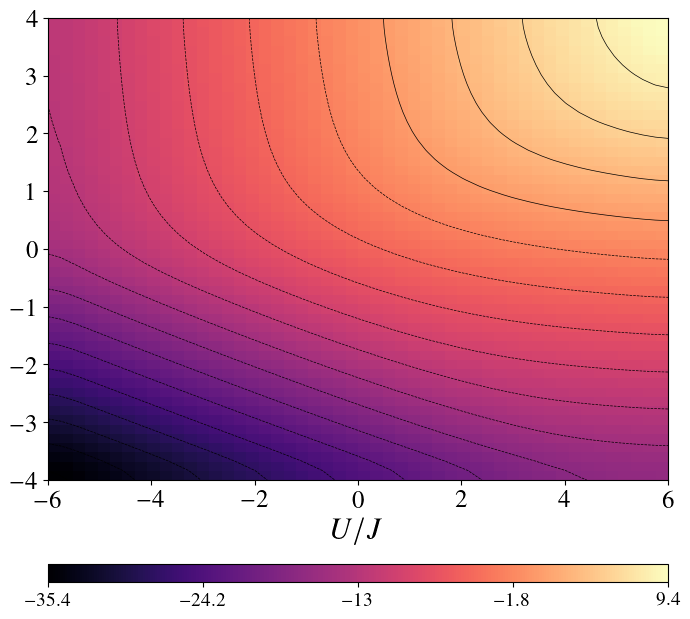

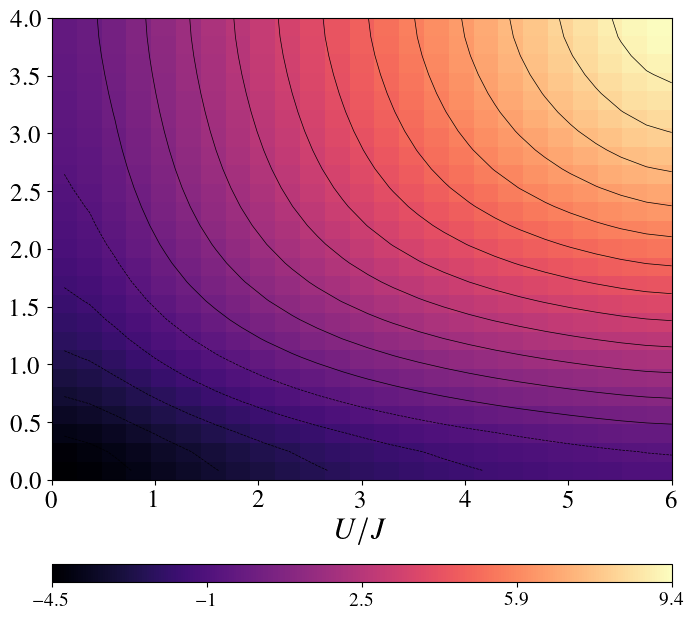

In [89]:
plot_phase_diagram(E_GS, U_vals, V_vals, 
                   r"$U/J$", r"$V/J$", r"$E_\text{GS}$", 
                   fig_path.replace("XXXXX", f"E_GS_smoothed_L={L}_NPoints={N_Points}.png"),
                   np.min(U_vals), np.min(V_vals), theme = "magma")
plot_phase_diagram(E_GS, U_vals, V_vals, 
                   r"$U/J$", r"$V/J$", r"$E_\text{GS}$", 
                   fig_path.replace("XXXXX", f"E_GS_smoothed_L={L}_NPoints={N_Points}_mask.png"),
                   0.0, 0.0, theme = "magma")

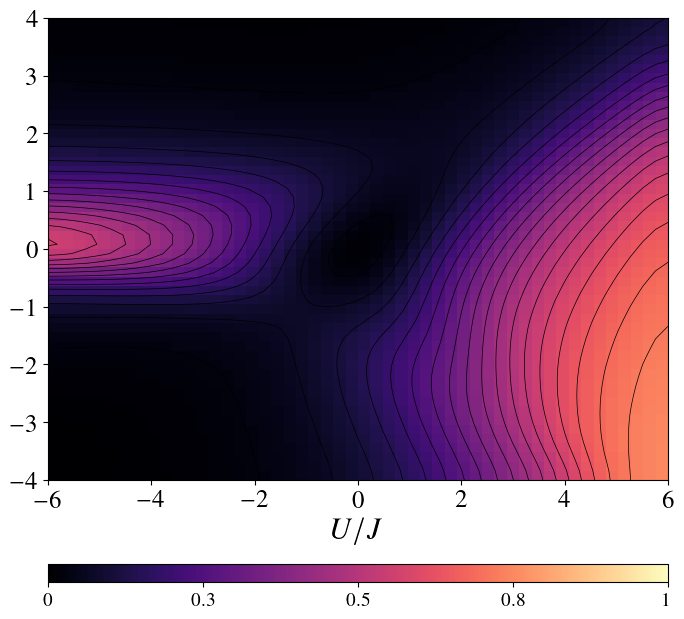

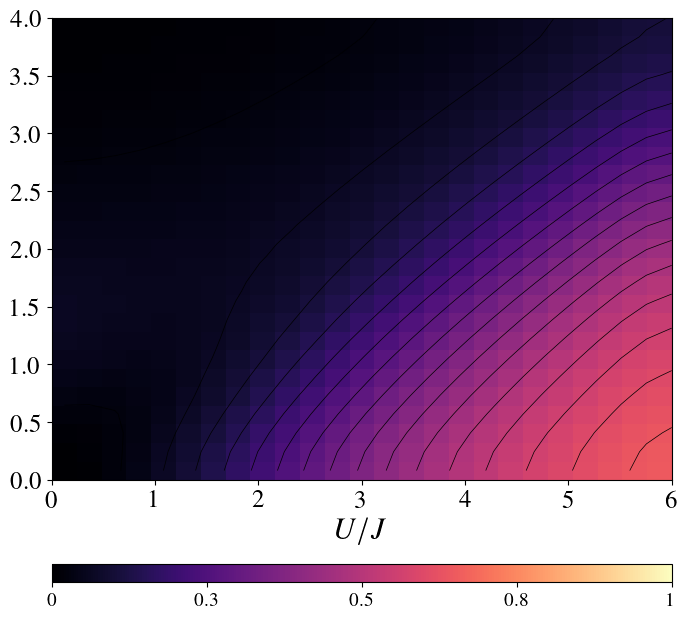

In [96]:
plot_phase_diagram(Q_2, U_vals, V_vals, 
                   r"$U/J$", r"$V/J$", r"$Q_2$", 
                   fig_path.replace("XXXXX", f"Q_2_smoothed_L={L}_NPoints={N_Points}.png"),
                   np.min(U_vals), np.min(V_vals), theme = "magma", upper_bound=1.0)

plot_phase_diagram(Q_2, U_vals, V_vals, 
                   r"$U/J$", r"$V/J$", r"$Q_2$", 
                   fig_path.replace("XXXXX", f"Q_2_smoothed_L={L}_NPoints={N_Points}_mask.png"),
                   0.0, 0.0, theme = "magma", upper_bound=1.0)

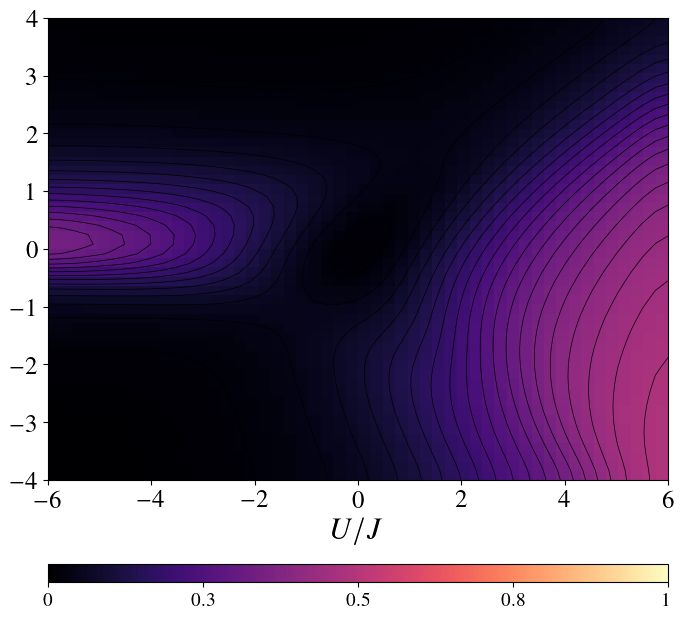

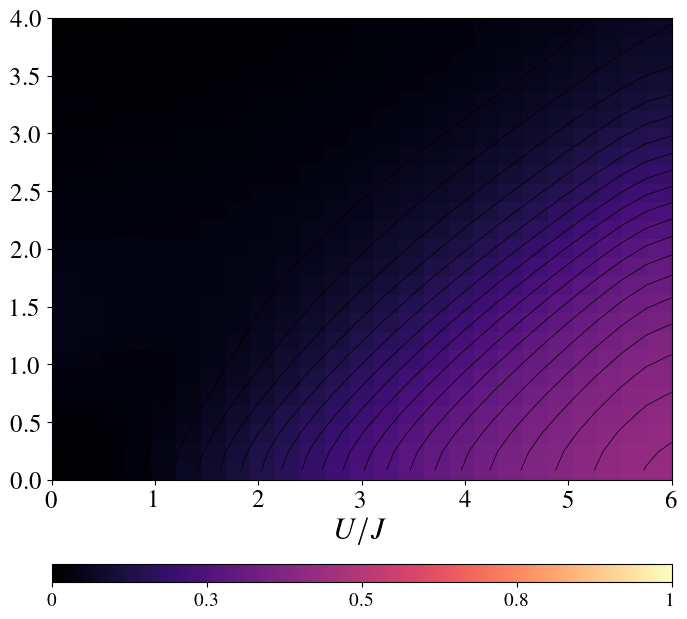

In [91]:
plot_phase_diagram(E_p, U_vals, V_vals, 
                   r"$U/J$", r"$V/J$", r"$E_p$", 
                   fig_path.replace("XXXXX", f"E_p_smoothed_L={L}_NPoints={N_Points}.png"),
                   np.min(U_vals), np.min(V_vals), theme = "magma", upper_bound=1.0)

plot_phase_diagram(E_p, U_vals, V_vals, 
                   r"$U/J$", r"$V/J$", r"$E_p$", 
                   fig_path.replace("XXXXX", f"E_p_smoothed_L={L}_NPoints={N_Points}_mask.png"),
                   0.0, 0.0, theme = "magma", upper_bound=1.0)

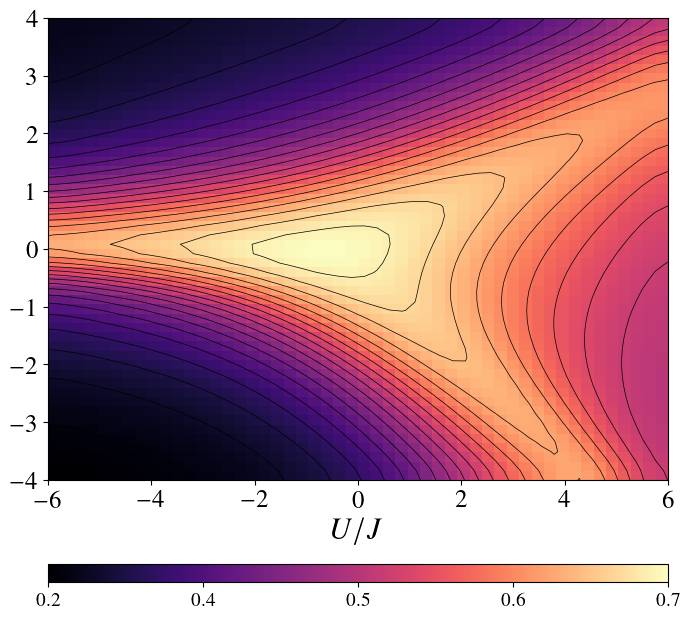

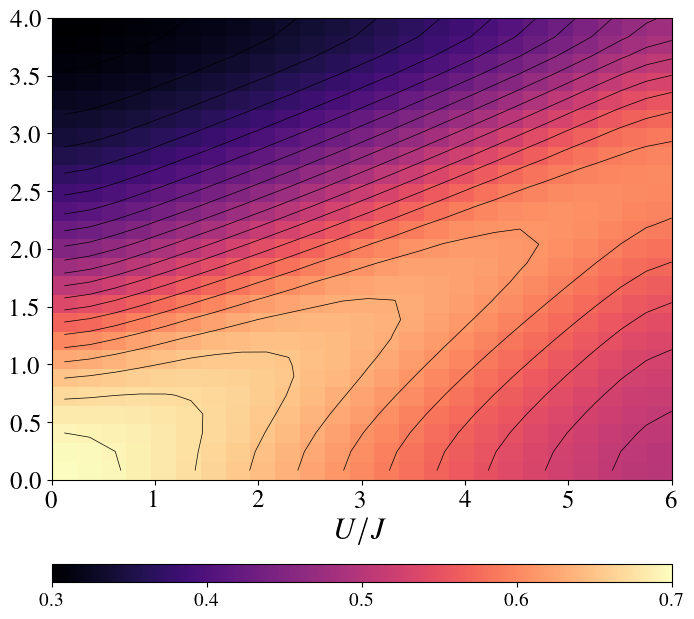

In [92]:
plot_phase_diagram(quantum_coherence_1, U_vals, V_vals, 
                   r"$U/J$", r"$V/J$", r"$C_{\ell_1}(\hat{\rho}_1)$", 
                   fig_path.replace("XXXXX", f"quantum_coherence_1rdm_smoothed_L={L}_NPoints={N_Points}.png"),
                   np.min(U_vals), np.min(V_vals), theme = "magma")

plot_phase_diagram(quantum_coherence_1, U_vals, V_vals, 
                   r"$U/J$", r"$V/J$", r"$C_{\ell_1}(\hat{\rho}_1)$", 
                   fig_path.replace("XXXXX", f"quantum_coherence_1rdm_smoothed_L={L}_NPoints={N_Points}_mask.png"),
                   0.0, 0.0, theme = "magma")

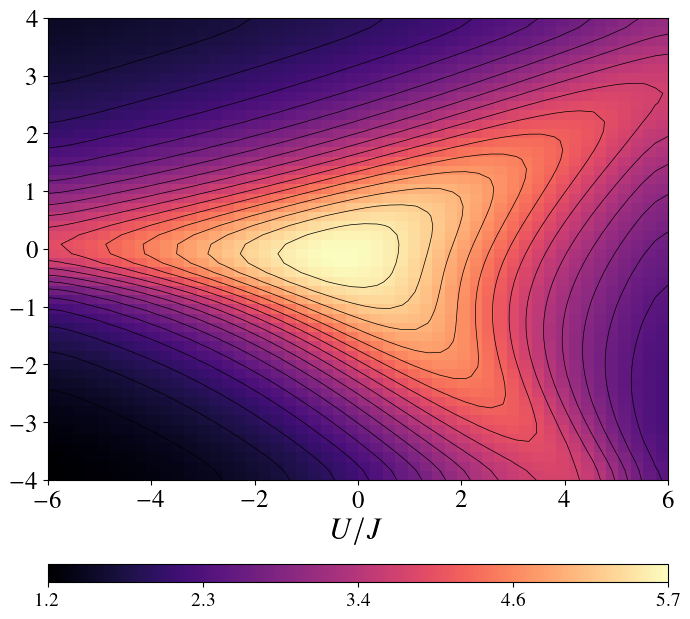

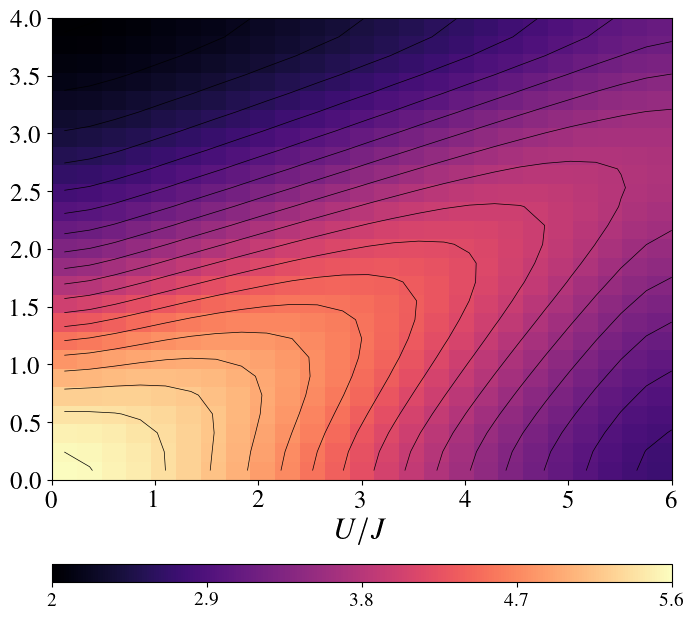

In [95]:
plot_phase_diagram(quantum_coherence_2, U_vals, V_vals, 
                   r"$U/J$", r"$V/J$", r"$C_{\ell_1}(\hat{\rho}_2)$", 
                   fig_path.replace("XXXXX", f"quantum_coherence_2rdm_smoothed_L={L}_NPoints={N_Points}.png"),
                   np.min(U_vals), np.min(V_vals), theme = "magma")
plot_phase_diagram(quantum_coherence_2, U_vals, V_vals, 
                   r"$U/J$", r"$V/J$", r"$C_{\ell_1}(\hat{\rho}_2)$", 
                   fig_path.replace("XXXXX", f"quantum_coherence_2rdm_smoothed_L={L}_NPoints={N_Points}_mask.png"),
                   0.0, 0.0, theme = "magma")

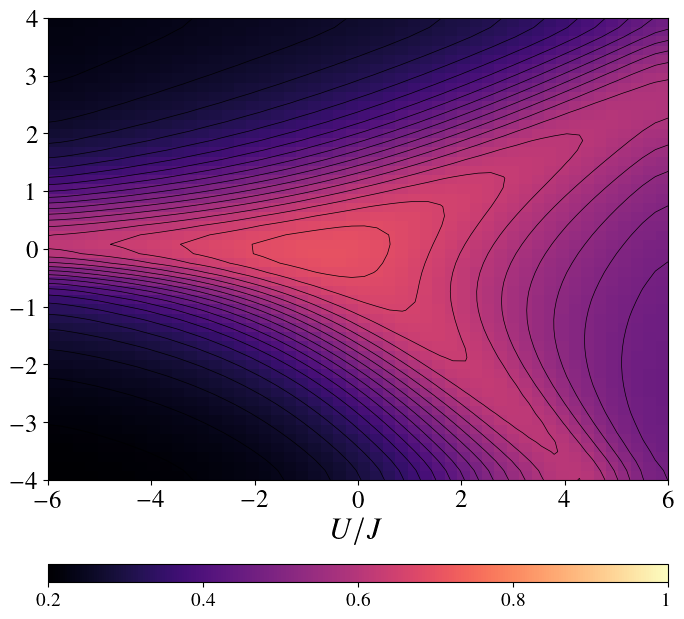

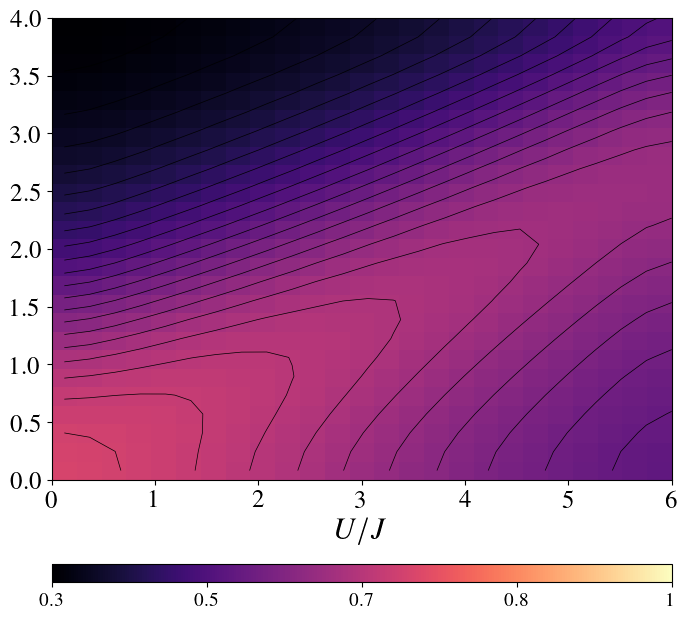

In [94]:
plot_phase_diagram(avg_linear_entropy, U_vals, V_vals, 
                   r"$U/J$", r"$V/J$", r"$\bar{\mathcal{L}}$", 
                   fig_path.replace("XXXXX", f"avg_single_site_entanglement_smoothed_L={L}_NPoints={N_Points}.png"),
                   np.min(U_vals), np.min(V_vals), theme = "magma", upper_bound=1.0)

plot_phase_diagram(avg_linear_entropy, U_vals, V_vals, 
                   r"$U/J$", r"$V/J$", r"$\bar{\mathcal{L}}$", 
                   fig_path.replace("XXXXX", f"avg_single_site_entanglement_smoothed_L={L}_NPoints={N_Points}_mask.png"),
                   0.0, 0.0, theme = "magma", upper_bound=1.0)